# USPS Fraud Detection 
### with Louvain Community Detection Algorithm on a Graph Network
#### Demonstration Notebook


### Contents:
1. [Import libraries and data](#Section-1:-Import-libraries-and-data)
2. [Community Detection](#Community-Detection)
3. [Results](#Results)
4. [Visualizations](#Visualizations)

**Note**: This notebook is intended for demonstration purposes, therefore the bulk of the code that
manipulates the data and runs the calculation is abstracted away in separate python modules that
can be found in this repository in the `scripts` folder. 


#### Section 1: Import libraries and data

In [1]:
from scripts.community_scoring import *
from scripts.graph_connector import query_executor
from scripts.louvain_community_detection import *
from scripts.sample_queries import *
from scripts.community_plots import *
from scripts.neo4j_to_networkx import graph_from_cypher


**Query data from Neo4j Graph database**

In [2]:
# query neo4j and read into in-memory graph
data = query_executor(query_all_data)

**Read data into in-memory graph**

In [3]:
graph = graph_from_cypher(data)

total nodes: 22320, total edges: 29590


<a id='Community'></a>
#### Section 2: Community Detection

In [4]:
communities = louvain_community(graph)

Generating communities...
Community detection elapsed time: 1.1954114437103271
total communities with more than one node: 64


<a id='Results'></a>
#### Section 3: Results

In [5]:
df_communities_stats = get_communities_stats(graph,communities)
df_sorted = df_communities_stats.sort_values(by='Score', ascending=False).reset_index()
df_percentages = composition_percentages(df_sorted)

**Below:** there were 58 communities generated by the algorithm that had a node count greater than 1 and a Fraud Density greater than 0.0. After measuring both the density of the community, and the density of the fraud, the geometric mean was calculated for the two scores. The two measurements, and the score, are seen below in the columns `Density`, `Fraud_Density`, and `Score` respectively. The rows below represent every tenth row to show a sorted distribution of scores, from the highest ranking community to the lowest ranking. 

In [6]:
result_sample = df_percentages.iloc[[0, 10, 20, 30, 40, 50]]
result_sample[["Density","Fraud_Density","Score","N_Nodes","N_Edges"]]

,Density,Fraud_Density,Score,N_Nodes,N_Edges
0,0.400000,0.600000,0.489898,5,4
10,0.285714,0.190476,0.233285,7,6
20,0.013897,0.005504,0.008746,171,202
30,0.019417,0.000747,0.003808,104,104
40,0.007804,0.000572,0.002112,265,273
50,0.001083,0.000531,0.000758,2548,3513


<a id='Visualizations'></a>
#### Section 4: Visualizations 

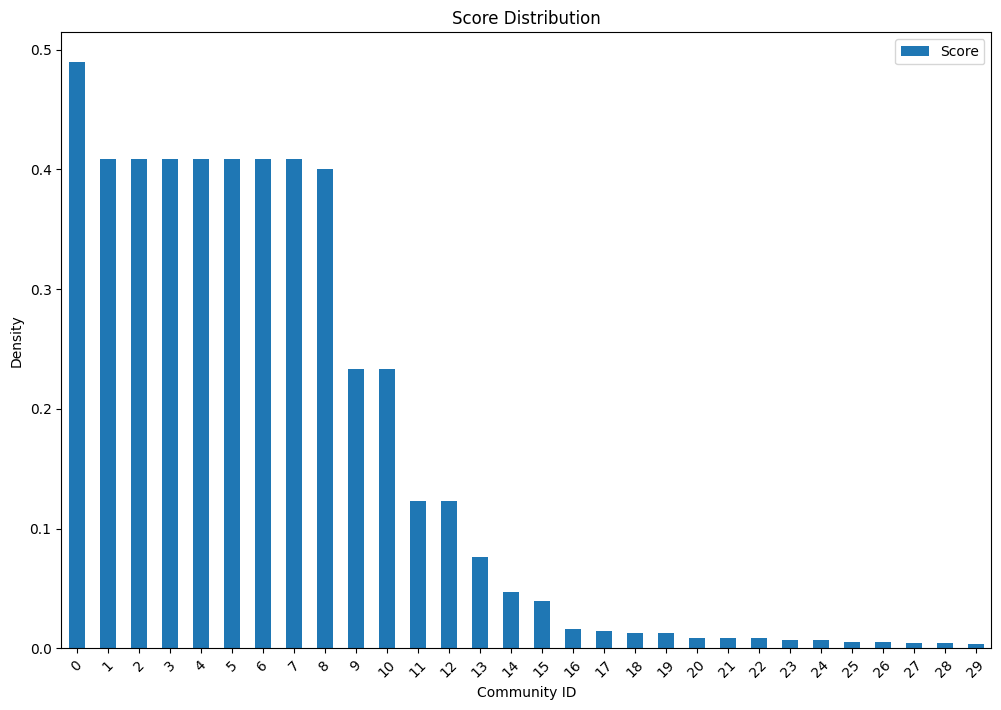

In [7]:
%matplotlib inline
rows = list(range(0, 30))
standard_plot(
    df_percentages, 
    type='bar', 
    rows=rows, 
    cols='Score', 
    title='Score Distribution', 
    x_label='Community ID', 
    y_label='Density'
)

#### Density and Fraud Score Distribution

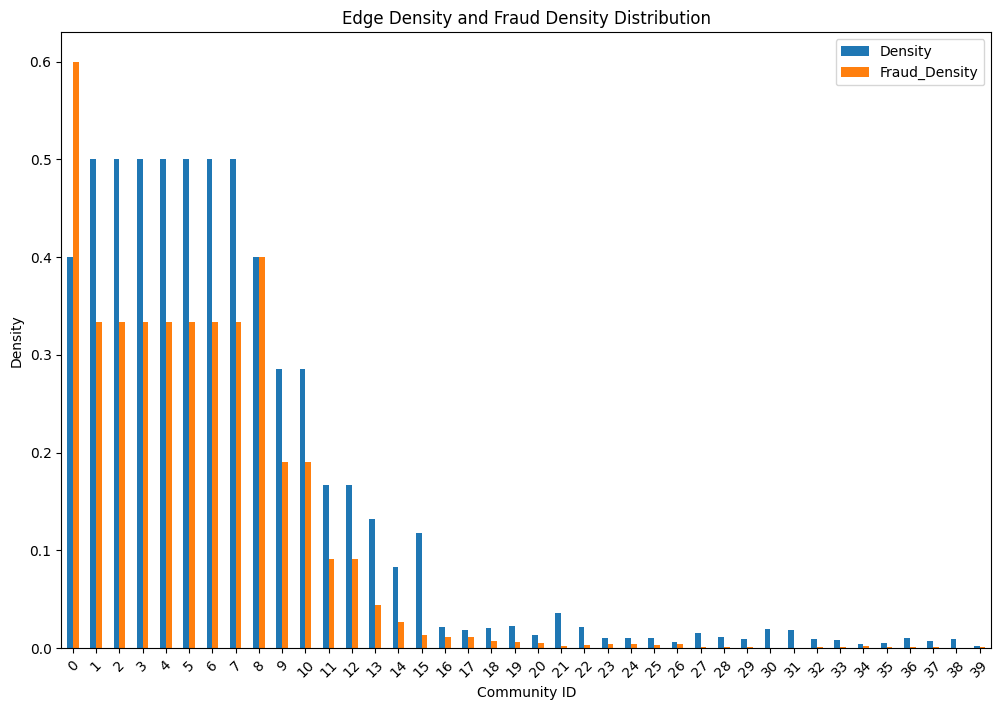

In [8]:
rows = list(range(0, 40))
standard_plot(
    df_percentages, 
    type='bar', 
    rows=rows, 
    cols='Density', 
    title='Edge Density and Fraud Density Distribution', 
    x_label='Community ID', 
    y_label='Density'
)

1. Show the visualization of the community structure for community rank #11
2. The bold lines indicate potential fraud

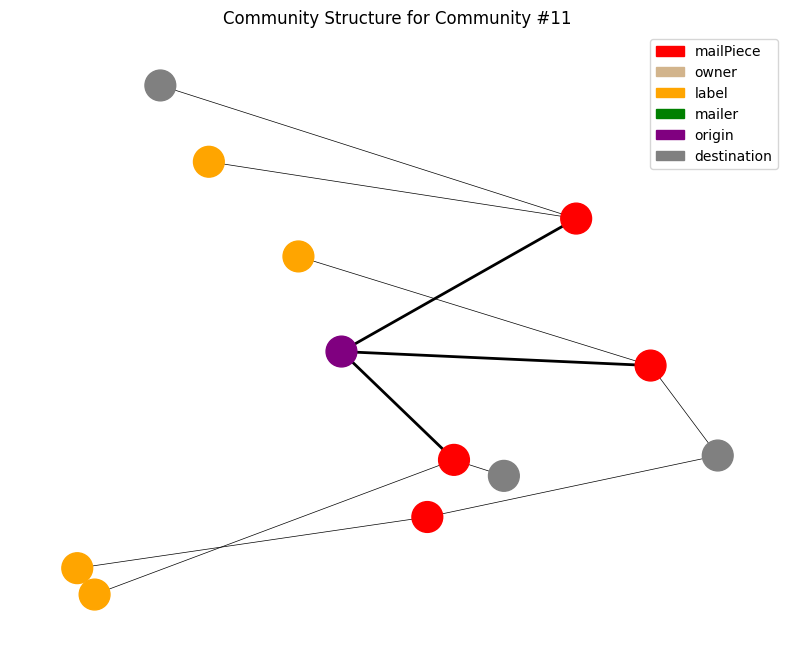

In [9]:
single_community = select_community(df_sorted, communities, 11)
sub_graph = make_subgraph(graph, single_community)
draw_single_community(sub_graph, single_community, 11)


## Section 5 - 
Below is an enumerated list of downstream tasks that could be performed after communities are identified and scored. 

1. Three mailPieces coming from the same origin (purple) had potential fraud indicators showing `firstzip_startzip_diff`.
    - The fraud indicators manifest as bold lines between nodes. 
2. Get the node ID for the origin (purple) and for each of the mailPieces (red) and query the properties of the associated nodes for their properties. 
3. Additionally, query to get the mailer and owner nodes that are associated with each of the potentially fraudulent mailPieces. 
4. Run comparison algorithms on the properties of MID and Owner nodes, and the mailPiece nodes to determine similarity and expose patterns. 
5. Make determination if further investigation is required to identify actual fraud or run proprietary fraud algorithms on the associated MIDs. 

In [10]:
# Community 60 has score rank of #11: 
# get the ID of the origin node
origin_node = [node for node, data in sub_graph.nodes(data=True) if data['labels'] == frozenset({'origin'})]
origin_node
        

[14027]

1. In the step above, we obtained the node id for the purple origin node in the visualization. 
2. Next we will use that node ID to get the IDs of the three mail pieces that are connected to the purple origin node. 

In [11]:
# get the IDs of the three mailPieces connected to the origin node
suspect_mailPieces = [node2 for node1, node2 in sub_graph.edges() if node1 in origin_node]
suspect_mailPieces

[4346, 6386, 7638]

1. With the three suspect mail piece id's obtained in the step above, display the properties of each mail piece. 

In [12]:
# display the properties of each mailPiece
print(sub_graph.nodes[4346]['properties'])
print(sub_graph.nodes[6386]['properties'])
print(sub_graph.nodes[7638]['properties'])

{'USPSDimensionalHeight': '1.5', 'USPSDimensionalWidth': '8.4', 'customerrecordstartdate': '2024-03-11', 'mailpieceid': 'f9333dc5556e85ac379b0940ec39e9a3af41b0f11be2ba8ab8ec3d4a099c1941', 'USPSDimensionalLength': '9.2'}
{'USPSDimensionalHeight': '0.8', 'USPSDimensionalWidth': '4.2', 'customerrecordstartdate': '2024-03-11', 'mailpieceid': 'c526ea5a2ea2c5aad299eb07f765ff0585f400451b509b40e45b12c755b03fe4', 'USPSDimensionalLength': '8.3'}
{'USPSDimensionalHeight': '1.57', 'USPSDimensionalWidth': '4.72', 'customerrecordstartdate': '2024-03-11', 'mailpieceid': '41eebc67c686b31d88566d2795b75bd7f5565ad7d65963eb6fea6f3b862b85c9', 'USPSDimensionalLength': '7.09'}


1. Each of the suspect mail pieces was shipped on the same day and have the same origin information. 
2. Below, find the mailer ID that is associated with each mail piece. 

In [13]:
# show the MIDs that are connected to each mail piece
suspect_mids = [(node1, node2, data) for node1, node2, data in graph.edges(data=True) if node2 in suspect_mailPieces]
suspect_mids

[(7, 4346, {'type_': 'mails', 'properties': {'weight': 1}}),
 (7, 6386, {'type_': 'mails', 'properties': {'weight': 1}}),
 (7, 7638, {'type_': 'mails', 'properties': {'weight': 1}})]

1. The information above shows that the three suspect mail pieces have the same mailer ID. 
2. This is very suspicious, and further investigation maybe required. Or delink the MID based on having three violations in the same day. 
3. Below the information for the MID owner is retrieved and displayed. 

In [14]:
# show the owner of the MID with ID 7
suspect_mid = 7
neighbors = list(graph.neighbors(suspect_mid))
property_value = 'owner'
owner_nodes = [node for node in neighbors if list(graph.nodes[node]['labels'])[0] == property_value]
graph.nodes[201]

{'labels': frozenset({'owner'}),
 'properties': {'CRID_msp_flag': 'N',
  'CRID': 'e47bf70942539edfdb028f67e9d92939904a13c9011a58d579211822ee3209ba',
  'CRID_cmra_flag': False,
  'UBK': '2e231182c525d356daba93fc304ed375b9a7df50fed9058d8fa42f50ccd34ac6'}}

#### Section 6: Conclusion

- Community 11 showed that the three suspect mail pieces had were mailed using the same mailer ID and were owned by a single owner. 
- The sample workflow presented above highlights a potential workflow that could be established to investigate each community. 
- A more sophisticated method or algorithm could be developed to conduct this process or provide further analysis on the communities. 
- The workflow above demonstrates the effectiveness and the application of the community detection algorithm and how it is relevant to finding fraud patterns. 